# Модель оценки рисков задержки доставки 

**Заказчик**
- междунароная компания CargaPronto - крупнейший логистический оператор

**Цель**
- разработать систему поддержки принятия решений для логистов CargaPronto

**Бизнес-требования**
- В момент оформления заказа система должна в реальном времени оценивать риск задержки и выдавать рекомендацию о смене приоритета доставки, если риск задержки высокий

**ML постановка.**

- тип: обучение с учителем
- подтип: бинарная классификация

**Инструменты**

- Логистическая регрессия. Она ценится в бизнесе за высокую скорость и прозрачность, позволяет оценить «нижнюю планку» качества до применения сложных алгоритмов.
- Модель градиентного бустинга CatBoost, способная находить сложные закономерности в данных.

**Метрика**
- ROC-AUC
- требования по метрике: ROC-AUC > 0.75.



##  Импорт библиотек, выполнение базовых настроек

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from typing import Optional

from phik import phik_matrix
from sklearn.model_selection import GroupShuffleSplit
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler, TargetEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

In [2]:
# воспроизводимость  вычислений
RANDOM_SEED = 42 

In [3]:
# настройка визуалиции 
plt.rcParams["figure.figsize"] = (12, 8)
pd.set_option('display.max_colwidth', None)

## Загрузка данных, первичный анализ

In [4]:
df_customers = pd.read_csv("https://code.s3.yandex.net/datasets/ds_s18_customers.csv")
df_orders = pd.read_csv("https://code.s3.yandex.net/datasets/ds_s18_orders.csv")

In [5]:
display(df_customers.info(), df_orders.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20652 entries, 0 to 20651
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   customer_id   20652 non-null  int64  
 1   customer_lat  20652 non-null  float64
 2   customer_lon  20652 non-null  float64
 3   total_sales   20652 non-null  float64
 4   total_orders  20652 non-null  int64  
 5   avg_discount  20652 non-null  float64
 6   return_rate   20652 non-null  float64
 7   recency       20652 non-null  int64  
dtypes: float64(5), int64(3)
memory usage: 1.3 MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 7 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   order_id            180519 non-null  int64  
 1   customer_id         180519 non-null  int64  
 2   late_delivery_risk  180519 non-null  int64  
 3   shipping_mode       180519 non-null  object 
 4

None

None

In [6]:
# определение категориальных и числовых типов
CAT_COLS_TYPES = ['object', 'category']
NUM_COLS_TYPES = [np.number]

def get_cat_num_cols(df: pd.DataFrame) -> tuple[list[str], list[str]]:
    """Получить списки названий категориальных и числовых столбцов"""
    cat_cols = df.select_dtypes(include=CAT_COLS_TYPES).columns.tolist()
    num_cols = df.select_dtypes(include=NUM_COLS_TYPES).columns.tolist()

    return cat_cols, num_cols

def get_base_df_info(name: str, df: pd.DataFrame):
    """Информация о датафрейме для ИАД анализа"""
    
    rows_count, cols_count = df.shape
    missing = df.isna().sum()
    missing_share = (missing / rows_count * 100).round(2) if rows_count else pd.Series(0, index=df.columns, dtype=float)
    duplicates_count = (df.duplicated().sum() / rows_count * 100).round(2)
    unique_values = df.nunique(dropna=False)

    cat_cols, num_cols = get_cat_num_cols(df=df)

    overview_df = pd.DataFrame({
        'Метрика': ['Строк', 'Колонок', 'Явных дубликатов, %', 'Категориальных колонок', 'Числовых колонок'],
        'Значение': [rows_count, cols_count, duplicates_count, int(len(cat_cols)), int(len(num_cols))],
    })

    summary_df = pd.DataFrame({
        'Тип данных': df.dtypes.astype(str),
        'Пропуски': missing,
        'Доля пропусков, %': missing_share,
        'Уникальные значения': unique_values,
    }).sort_values(by=['Пропуски', 'Уникальные значения'], ascending=[False, False])

    cols_df = pd.DataFrame({
        'Категориальные колонки': pd.Series(cat_cols),
        'Числовые колонки': pd.Series(num_cols),
    })

    print(f'Общая информация о датафрейме {name}')
    display(df.head())
    display(overview_df)

    print('Сводка по признакам')
    display(summary_df)

    print('Типы колонок')
    display(cols_df)
    print('-'*50)

In [7]:
get_base_df_info(name='customers', df=df_customers)

Общая информация о датафрейме customers


,customer_id,customer_lat,customer_lon,total_sales,total_orders,avg_discount,return_rate,recency
0,1,25.953648,-97.507683,472.450012,1,0.060,0.0,793
1,2,38.375595,-104.726021,1618.660042,4,0.126,0.0,137
2,3,18.025375,-66.615082,3189.200037,5,0.105,0.0,230
3,4,33.670021,-112.247078,1480.709993,4,0.135,0.0,381
4,5,18.359104,-66.077911,1101.919998,3,0.140,0.0,458


,Метрика,Значение
0,Строк,20652.0
1,Колонок,8.0
2,"Явных дубликатов, %",0.0
3,Категориальных колонок,0.0
4,Числовых колонок,8.0


Сводка по признакам


,Тип данных,Пропуски,"Доля пропусков, %",Уникальные значения
customer_id,int64,0,0.0,20652
customer_lat,float64,0,0.0,12769
total_sales,float64,0,0.0,12632
avg_discount,float64,0,0.0,10600
customer_lon,float64,0,0.0,6161
recency,int64,0,0.0,1012
return_rate,float64,0,0.0,166
total_orders,int64,0,0.0,15


Типы колонок


,Категориальные колонки,Числовые колонки
0,NaN,customer_id
1,NaN,customer_lat
2,NaN,customer_lon
3,NaN,total_sales
4,NaN,total_orders
5,NaN,avg_discount
6,NaN,return_rate
7,NaN,recency


--------------------------------------------------


In [8]:
get_base_df_info(name='orders', df=df_orders)

Общая информация о датафрейме orders


,order_id,customer_id,late_delivery_risk,shipping_mode,category_name,order_date,item_price
0,180517,20755,0,Standard Class,Sporting Goods,2018-01-31 22:56:00,327.75
1,179254,19492,1,Standard Class,Sporting Goods,2018-01-13 12:27:00,327.75
2,179253,19491,0,Standard Class,Sporting Goods,2018-01-13 12:06:00,327.75
3,179252,19490,0,Standard Class,Sporting Goods,2018-01-13 11:45:00,327.75
4,179251,19489,0,Standard Class,Sporting Goods,2018-01-13 11:24:00,327.75


,Метрика,Значение
0,Строк,180519.0
1,Колонок,7.0
2,"Явных дубликатов, %",0.0
3,Категориальных колонок,3.0
4,Числовых колонок,4.0


Сводка по признакам


,Тип данных,Пропуски,"Доля пропусков, %",Уникальные значения
order_id,int64,0,0.0,180519
order_date,object,0,0.0,65752
customer_id,int64,0,0.0,20652
item_price,float64,0,0.0,75
category_name,object,0,0.0,50
shipping_mode,object,0,0.0,4
late_delivery_risk,int64,0,0.0,2


Типы колонок


,Категориальные колонки,Числовые колонки
0,shipping_mode,order_id
1,category_name,customer_id
2,order_date,late_delivery_risk
3,NaN,item_price


--------------------------------------------------


Анализ:
- в обоих датасетах явных дублей и пропусков нет


### Проверка консистентности ID

In [9]:
# ID согласованы между датафреймами 
sorted(df_orders['customer_id'].unique().tolist()) == df_customers['customer_id'].values.tolist()


True

In [10]:

print('Каждый заказ имеет уникальный ID: ', df_orders['order_id'].nunique() == len(df_orders))
print('Каждый клиент уникален: ', df_customers['customer_id'].nunique() == len(df_customers))

Каждый заказ имеет уникальный ID:  True
Каждый клиент уникален:  True


Анализ:
- ID клиентов в датасете заказов согласуются с ID клиентов в датасете клиентов
- ID внутри соответствующих датафреймов уникальные

### Подготовка признаков с датой и временем

In [11]:
df_orders['order_date'] = pd.to_datetime(df_orders['order_date'])

In [12]:
df_orders['order_month'] = df_orders['order_date'].dt.month
df_orders['order_weekday'] = df_orders['order_date'].dt.weekday
df_orders['order_hour'] = df_orders['order_date'].dt.hour

In [13]:
df_orders = df_orders.drop(columns='order_date')

## EDA

На этом этапе ваша цель — исследовать структуру данных и подтвердить гипотезы транспортного департамента о «неоднородности» базы. Кроме того, вам предстоит изучить и удалить географические аномалии.

1. Проверьте баланс классов.
2. Выполните географический аудит.
3. Удалите аномалии.
4. Проанализируйте зависимости между признаками.



In [14]:
def plot_count_bars(
    df: pd.DataFrame, col_name: str,
    show_mean: bool = False
):
    """Столбчатые диаграммы распрелелений категориальных признаков"""
    counts = df[col_name].value_counts()
    freq_order = counts.index
    mean_value = counts.mean()

    ax = sns.countplot(data=df, x=col_name, order=freq_order)

    if show_mean:
        # горизонтальная линия среднего значения
        plt.axhline(
            y=mean_value,
            color="red",
            linestyle="--",
            linewidth=2,
            label=f"Среднее: {mean_value:.1f}",
        )
        plt.legend()

    plt.title(f"Распределение {col_name}")
    plt.ylabel("количество")
    plt.xticks(rotation=45)


    plt.ylim(top=plt.ylim()[1] * 1.05)

    plt.show()

In [15]:
def plot_hist_box(
    df: pd.DataFrame, 
    feature_name: str,
    x_label: str = 'значение',
    bins=30,
    hue: Optional[str]=None
):
    """Гистограмма + ящик с усами для анализа распределений количественных данных"""
    fig, axes = plt.subplots(nrows=2, ncols=1)
    axes[0].grid(True)
    axes[1].grid(True)
    sns.histplot(data=df, x=feature_name, stat='density', ax=axes[0], bins=bins, hue=hue, legend=True)
    
    plt.figtext(
        0.75,0.4, 
        df[feature_name].describe().to_string(), 
        fontsize=10,
        family="monospace",  # Ensures perfect columns alignment
        verticalalignment="center",
        bbox=dict(boxstyle="square,pad=0.6", facecolor="#f8f9fa", edgecolor="gray"),
    )

    sns.boxplot(data=df, x=feature_name, orient="h", ax=axes[1])
    axes[0].set_title(f'Распределение {feature_name}')
    axes[0].set_ylabel('плотность')
    axes[1].set_xlabel(x_label)
    axes[1].set_ylabel(feature_name)
    plt.show()

In [16]:
def show_category_parts(
    df_to_analyse: pd.DataFrame, 
    colname_groupby: str, 
    part_category: str, 
    title: str = '', 
    df_init: pd.DataFrame = None
):
    df_unstack = df_to_analyse.groupby(colname_groupby)[part_category].value_counts(normalize=True).unstack(fill_value=0)

    if True in df_unstack.columns:
        sort_col = True
    elif 1 in df_unstack.columns:
        sort_col = 1
    else:
        sort_col = df_unstack.columns[0]

    df_unstack = df_unstack.sort_values(by=sort_col, ascending=False)
    print(df_unstack)

    if df_init is not None:
        df_init_unstack = df_init.groupby(colname_groupby)[part_category].value_counts(normalize=True).unstack(fill_value=0)
        mean_share = df_init_unstack[sort_col].mean()
    else:
        mean_share = df_unstack[sort_col].mean()
    print(f'Средняя доля по "{sort_col}": {mean_share:.1%}')


    ax = df_unstack.plot(kind='bar')


    plt.title(title)
    plt.ylabel('Доля') 
    plt.xlabel('Категория') 
    plt.xticks(rotation=45)  
    plt.legend()  

    # Отображаем график
    plt.show()

### Таблица orders

In [17]:
cat_cols, num_cols = get_cat_num_cols(df=df_orders)
cat_cols, num_cols
order_feature_cols = cat_cols + num_cols
target_name = 'late_delivery_risk'
order_feature_cols = [name for name in order_feature_cols if name != target_name]

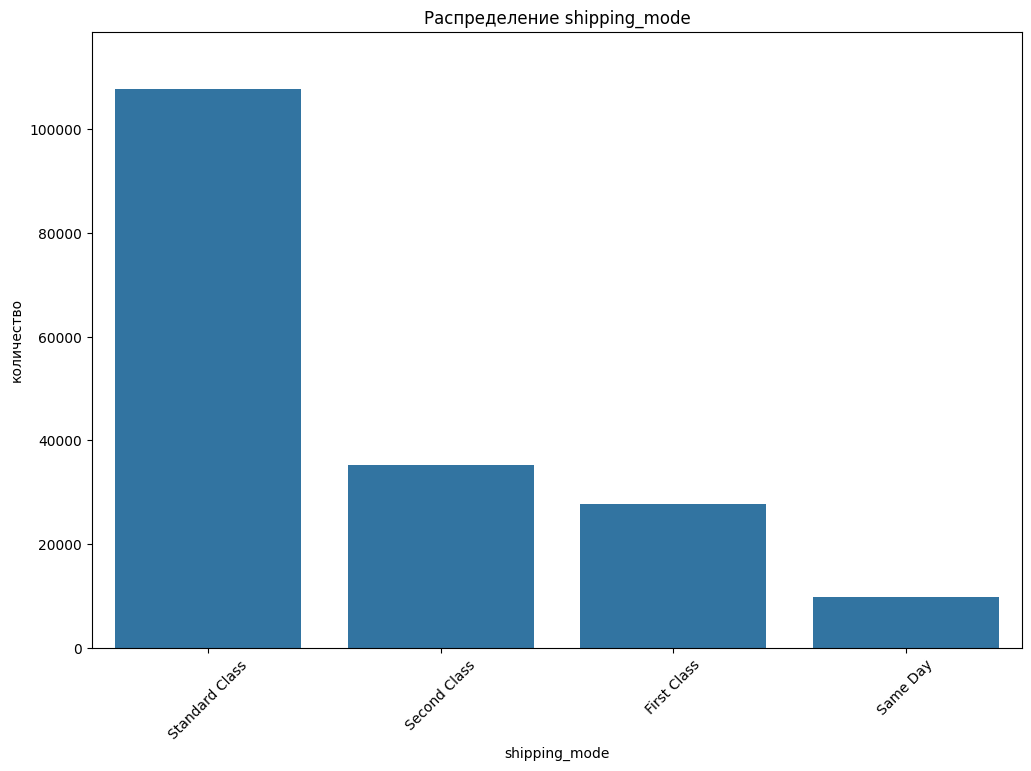

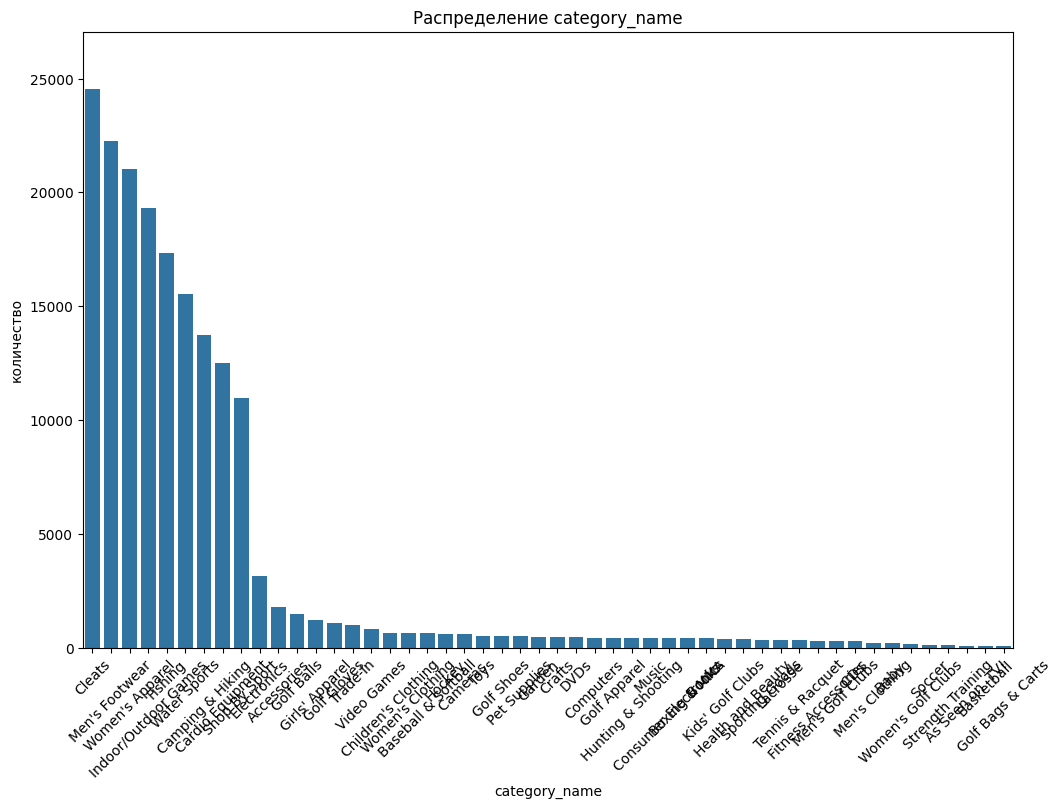

In [18]:
for name in cat_cols:
    plot_count_bars(df=df_orders, col_name=name)

Анализ:
- shipping_mode: существенно преобладает Standard Class - им чаще всего отправляют
- category_name: есть топ-9 категорий, которые существенно больше заказывают

late_delivery_risk         0         1
shipping_mode                         
First Class         0.046775  0.953225
Second Class        0.233672  0.766328
Same Day            0.542570  0.457430
Standard Class      0.619283  0.380717
Средняя доля по "1": 63.9%


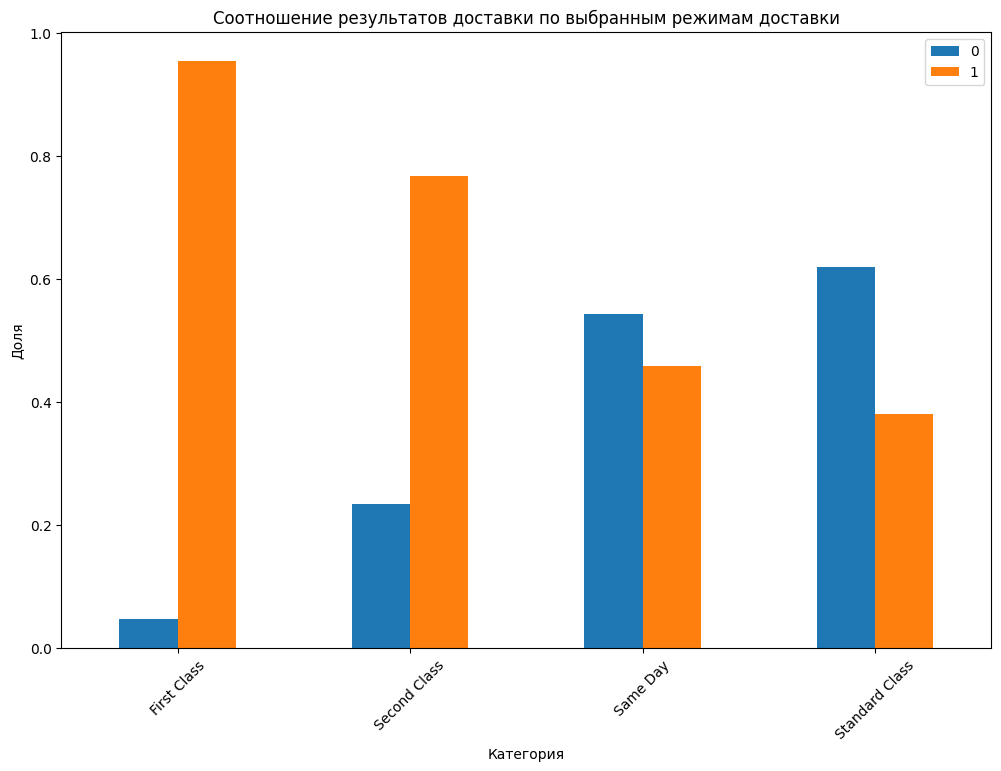

In [19]:
show_category_parts(
    df_orders, 
    colname_groupby='shipping_mode' , 
    part_category='late_delivery_risk',
    title='Соотношение результатов доставки по выбранным режимам доставки'
)

Анализ:
- категорий мало. На этапе предобработки можно воспользоваться one-hot кодированием 
- доля задержек в первом и втором режиме доставки существенно выше, чем в остальных

late_delivery_risk           0         1
category_name                           
Golf Bags & Carts     0.311475  0.688525
Lacrosse              0.399417  0.600583
Pet Supplies          0.410569  0.589431
Cameras               0.418919  0.581081
Strength Training     0.423423  0.576577
As Seen on  TV!       0.426471  0.573529
Music                 0.428571  0.571429
Accessories           0.430337  0.569663
Fitness Accessories   0.430421  0.569579
Books                 0.434568  0.565432
Women's Clothing      0.435385  0.564615
Boxing & MMA          0.437352  0.562648
Golf Gloves           0.437383  0.562617
Hunting & Shooting    0.438636  0.561364
Electronics           0.439163  0.560837
Crafts                0.440083  0.559917
Health and Beauty     0.441989  0.558011
Tennis & Racquet      0.442073  0.557927
Garden                0.442149  0.557851
Trade-In              0.443532  0.556468
Golf Shoes            0.444656  0.555344
Sporting Goods        0.445378  0.554622
Girls' Apparel  

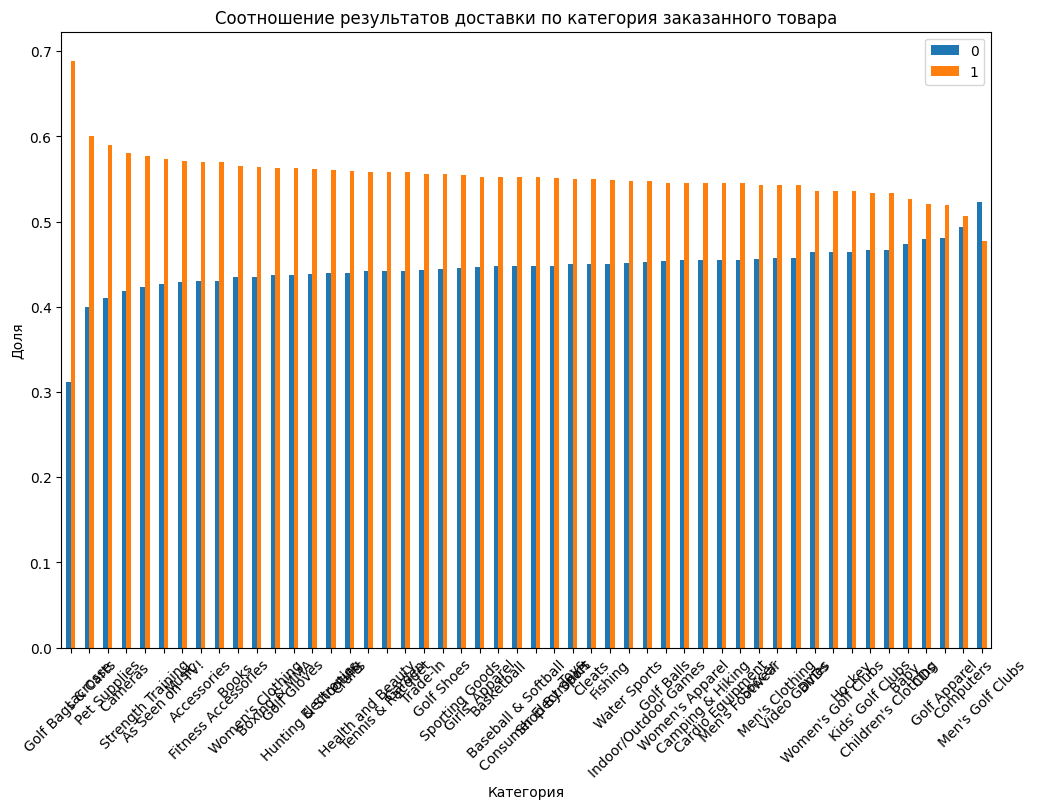

In [20]:
show_category_parts(
    df_orders, 
    colname_groupby='category_name' , 
    part_category='late_delivery_risk',
    title='Соотношение результатов доставки по категория заказанного товара'
)

Анализ:
- кол-во категорий большое (>10). Чтобы не раздувать признаковое пространство, необходимо воспользоваться TargetEncoding 
- в большинстве категорий товаров доля задержек преобладает
- в категории **Golf Bags & Carts** задержек около 68% - рекордный показатель
- в единственной категории **Men's Golf Clubs** задержек меньше, чем своевременных заказов

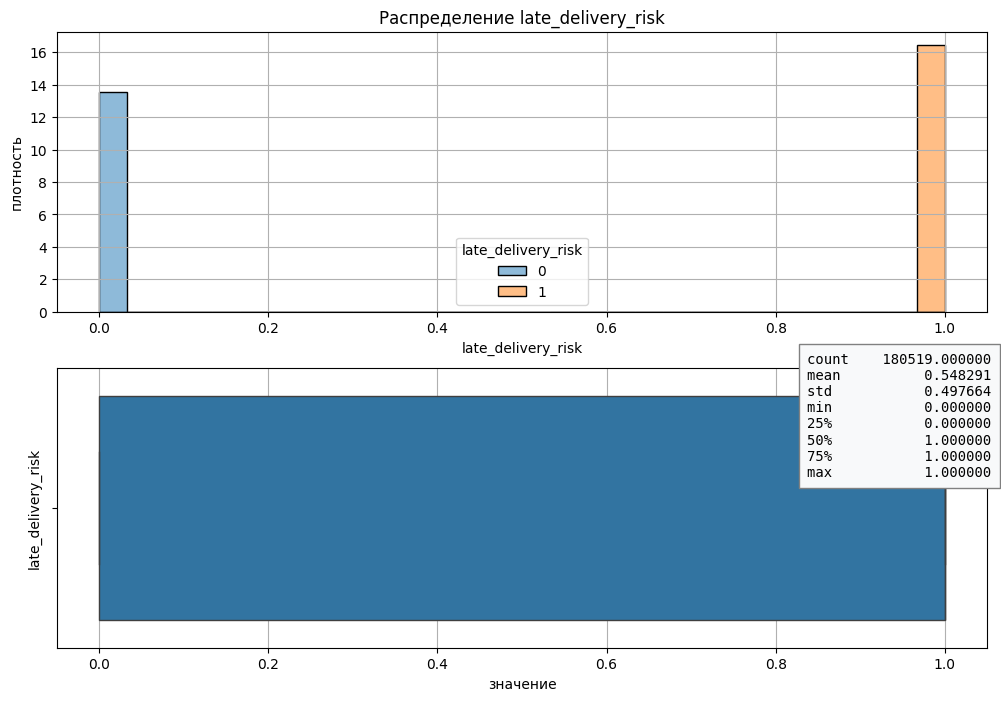

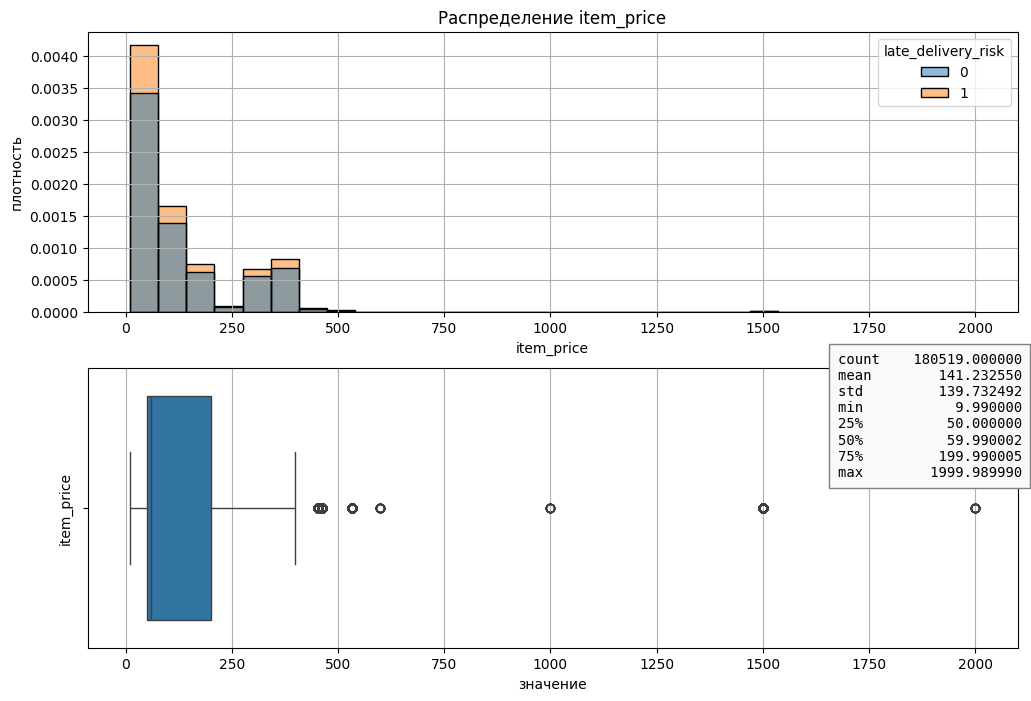

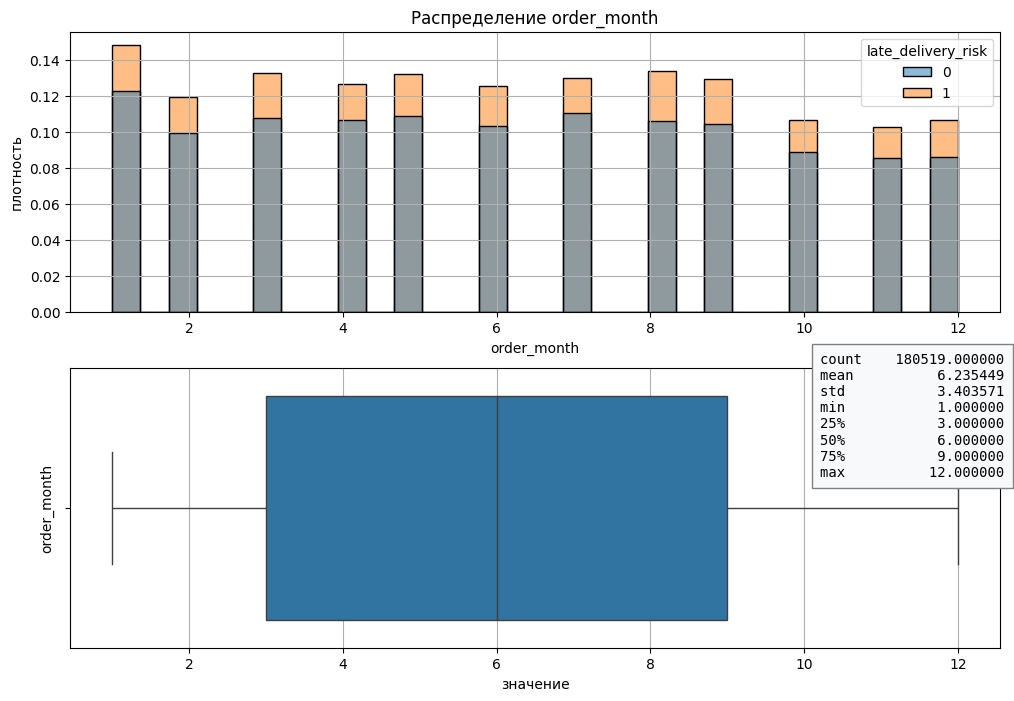

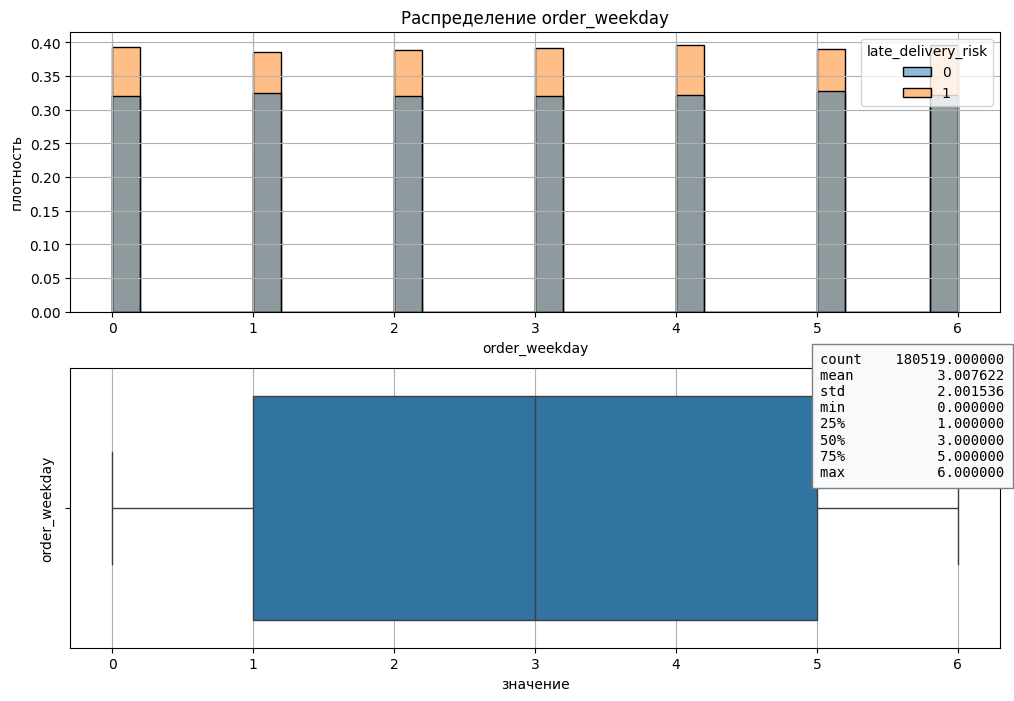

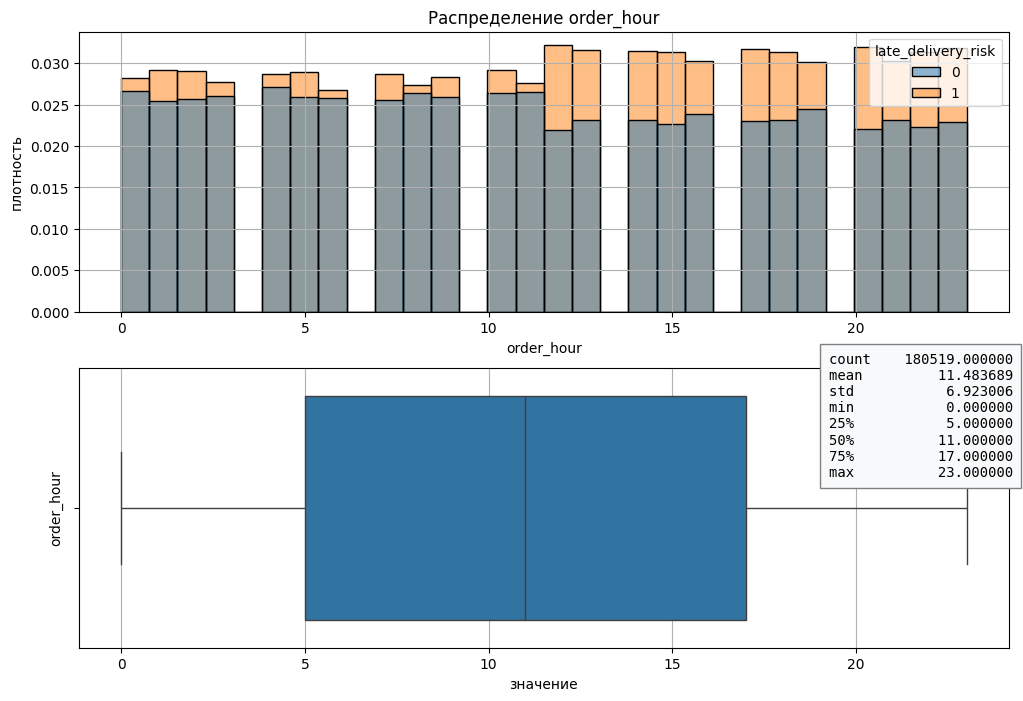

In [21]:
num_cols = [name for name in num_cols if name not in ['order_id', 'customer_id']]
for name in num_cols:
    plot_hist_box(df=df_orders, feature_name=name, hue=target_name)

In [22]:
df_orders[target_name].value_counts() / len(df_orders[target_name]) * 100

late_delivery_risk
1    54.829132
0    45.170868
Name: count, dtype: float64

Анализ:
- late_delivery_risk: дисбаланс классов для тергет переменной несущественный 55/45%
- item_price: распределение несимметричное, есть существенные выбросы с высокой ценой. Доля задержек выше у дешевых товаров
- по временным признакам распределения близкие к равномерным. Доля отказов увеличивается с 12 до 23 часов


### Корреляционный анализ

In [23]:
def get_corr_matrix(
    data: pd.DataFrame, feat_cols: list[str], 
    num_cols: list[str]
):
    """Матрица корреляций"""
    corr_matrix = data[feat_cols].phik_matrix(
        interval_cols=num_cols if len(num_cols) > 0 else None,
        njobs=-1,
    )

    return corr_matrix

def plot_corr_matrix(corr_matrix):
    """Тепловая карта"""
    plt.figure(figsize=(14, 10)) 

    sns.heatmap(data=corr_matrix, annot=True, fmt='.2f', linewidths=0.5, cmap='viridis')

    plt.title('Тепловая карта матрицы корреляций')
    plt.show()

def corr_with_target(corr_matrix, target_col_name):
    """Корреляция с таргетом"""
    return corr_matrix[target_col_name].sort_values(ascending=False)

In [24]:
corr_matrix = get_corr_matrix(
    data=df_orders, 
    feat_cols=num_cols + cat_cols, 
    num_cols=num_cols
)

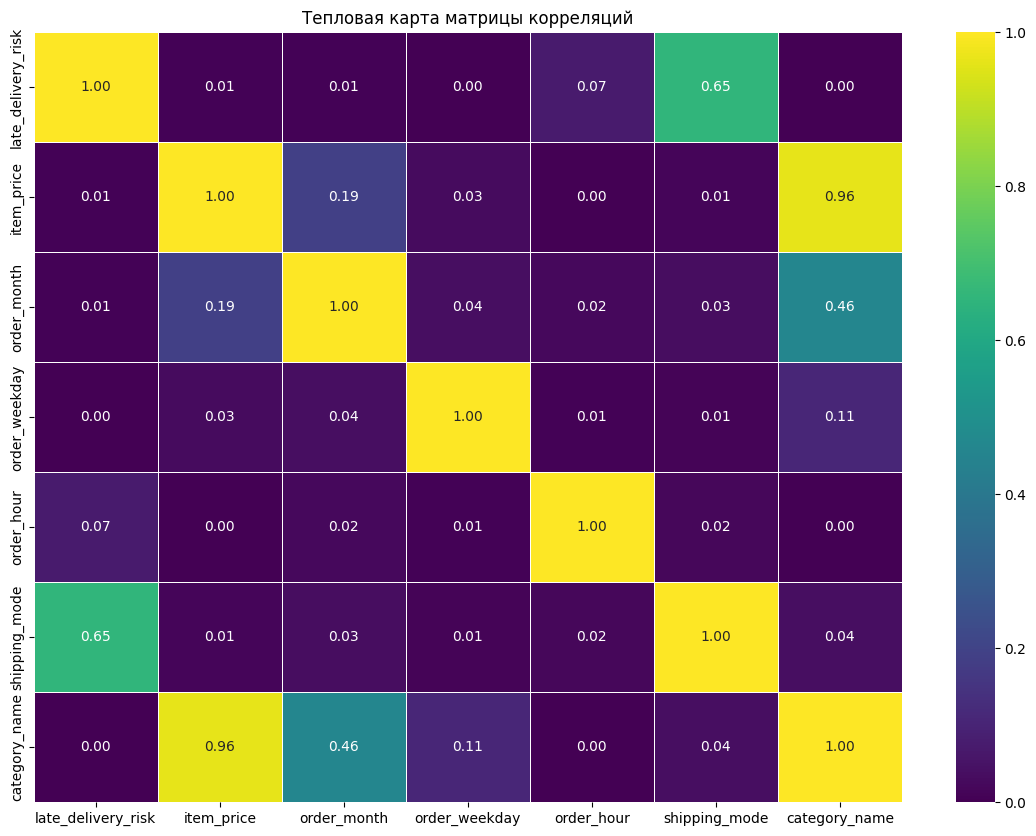

In [25]:
plot_corr_matrix(corr_matrix)

Анализ:
- категория товара сильно коррелирует с ценой: corr = 0.96. Можно предположить, что товары одной категории имеют один ценовой сегмент
- наибольшая по модулю корреляция с таргетом у shipping_mode. Похоже, что режим доставки сильнее остальных признаков связан с вероятностью задержки

### Вывод по ИАД

Таргет:
- дисбаланс классов для тергет переменной несущественный 55/45%

Количественные признаки:
- item_price: распределение несимметричное, есть существенные выбросы с высокой ценой. Доля задержек выше у дешевых товаров.
- по временным признакам распределения близкие к равномерным. Доля отказов увеличивается с 12 до 23 часов

Категориальные признаки:
- в большинстве категорий товаров доля задержек преобладает
- в категории **Golf Bags & Carts** задержек около 68% - рекордный показатель
- в единственной категории **Men's Golf Clubs** задержек меньше, чем своевременных заказов
- доля задержек в первом и втором режиме доставки существенно выше, чем в остальных
- shipping_mode: существенно преобладает Standard Class - им чаще всего отправляют
- category_name: есть топ-9 категорий, которые существенно больше заказывают

Корреляционный анализ:
- категория товара сильно коррелирует с ценой: corr = 0.96. Можно предположить, что товары одной категории имеют один ценовой сегмент
- наибольшая по модулю корреляция с таргетом у shipping_mode. Похоже, что режим доставки сильнее остальных признаков связан с вероятностью задержки

Комментарии для предобработки:
- category_name: более 10 уникальных категорий -> TargetEncoding
- shipping_mode: 4 уникальные категории -> OneHotEncoding

##  Разделение на выборки

- разбиение по группам: один и тот же клиент не должен попасть в разные выборки

In [40]:
# train_val - 80, test - 20
groups = df_orders['customer_id']
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_SEED)
train_val_idx, test_idx = next(gss.split(X=df_orders, groups=groups))

df_train_val = df_orders.iloc[train_val_idx]
df_test = df_orders.iloc[test_idx]

In [41]:
# train 60, val - 20
groups2 = df_train_val['customer_id']
gss2 = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=RANDOM_SEED)
train_idx, val_idx = next(gss2.split(X=df_train_val, groups=groups2))

df_train = df_train_val.iloc[train_idx]
df_val = df_train_val.iloc[val_idx]

In [42]:
display(df_train.shape, df_val.shape, df_test.shape)

(107515, 9)

(36242, 9)

(36762, 9)

Проверка разбиения:
- не должно быть совпадающих id ни в одной паре 

In [ ]:
train_id = df_train['customer_id'].values
val_id = df_val['customer_id'].values
test_id = df_test['customer_id'].values

id_combinations = list(combinations([train_id, val_id, test_id], 2))

for rhs, lhs in id_combinations:
    print('Повторы id: ', len(set(rhs) & set(lhs)))

Повторы:  0
Повторы:  0
Повторы:  0


Итог:
- разбиение на train - 60%, validate - 20%, test - 20% проведено корректно

In [62]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 107515 entries, 1 to 180516
Data columns (total 9 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   order_id            107515 non-null  int64  
 1   customer_id         107515 non-null  int64  
 2   late_delivery_risk  107515 non-null  int64  
 3   shipping_mode       107515 non-null  object 
 4   category_name       107515 non-null  object 
 5   item_price          107515 non-null  float64
 6   order_month         107515 non-null  int32  
 7   order_weekday       107515 non-null  int32  
 8   order_hour          107515 non-null  int32  
dtypes: float64(1), int32(3), int64(3), object(2)
memory usage: 7.0+ MB


## Пайплайн предобработки данных

In [71]:
def select_cat_one_hot(X):
    """Отбор категорий для OneHot кодирования"""
    cat_cols = X.select_dtypes(include=CAT_COLS_TYPES).columns.tolist()
    return [name for name in cat_cols if X[name].nunique() < 10]

def select_cat_target(X):
    """Отбор категорий для Target кодирования"""
    cat_cols = X.select_dtypes(include=CAT_COLS_TYPES).columns.tolist()
    return [name for name in cat_cols if X[name].nunique() >= 10]

def select_num_cols_continues(X):
    """Отбор непрерывных количественных признаков"""
    num_cols =X.select_dtypes(include=['float']).columns.tolist()
    return num_cols

def select_num_cols_discrete(X):
    """Отбор дискретных количественных признаков"""
    num_cols =X.select_dtypes(include=['int']).columns.tolist()
    return num_cols

In [72]:
def create_preprocessor(
) -> ColumnTransformer:
    """
    Создание предобратботчика данных.
    """

    # Пайплайны для разных типов признаков
    cat_one_hot_pipeline = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='first'))
    ])
    cat_target_pipeline = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', TargetEncoder())
    ])

    num_continues_cols_pipeline = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])

    num_discrete_cols_pipeline = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('scaler', MinMaxScaler())
    ])

    transformers = [
        ('cat_one_hot', cat_one_hot_pipeline, select_cat_one_hot),
        ('cat_target', cat_target_pipeline, select_cat_target),
        ('num_continues', num_continues_cols_pipeline, select_num_cols_continues),
        ('num_discrete', num_discrete_cols_pipeline, select_num_cols_discrete)
    ]
    
    preprocessor = ColumnTransformer(
        transformers=transformers,
        remainder='drop'
    )

    return preprocessor


## Обучение базовой модели

Прежде чем проверять гипотезу о сегментации и создавать при помощи кластеризации новые признаки, необходимо зафиксировать точку отсчёта. Вам нужно понять, какое качество прогноза задержек обеспечивают стандартные модели, используя только базовую информацию о самом заказе.

1. Выберите нужные признаки — используйте колонки таблицы `orders` (`shipping_mode`, `category_name`, `item_price`, `order_hour`,  `order_weekday` и `order_month`).

2. Обучите логистическую регрессию и `CatBoostClassifier` и оцените их качество.

3. Оцените качество обеих моделей на валидационной выборке.

Напоминаем, что на этапе построения базовой модели глубокий подбор гиперпараметров необязателен.

**Дополнительное задание.** Если вы чувствуете в себе силы, вы можете попробовать базовую оптимизацию, но помните: главная прибавка к качеству ожидается от новых признаков, которые вы создадите в следующих разделах.

In [ ]:
# признаки и таргет для обучения
baseline_features = ['shipping_mode', 'category_name', 'item_price', 'order_hour', 'order_weekday', 'order_month']
target_name = 'late_delivery_risk'

In [58]:
X_train = df_train[baseline_features]
y_train = pd.Series(data=df_train[target_name].values, name='target')

display(X_train.head(), y_train.head())

,shipping_mode,category_name,item_price,order_hour,order_weekday,order_month
1,Standard Class,Sporting Goods,327.75,12,5,1
2,Standard Class,Sporting Goods,327.75,12,5,1
3,Standard Class,Sporting Goods,327.75,11,5,1
4,Standard Class,Sporting Goods,327.75,11,5,1
6,First Class,Sporting Goods,327.75,10,5,1


0    1
1    0
2    0
3    0
4    1
Name: target, dtype: int64

### Обучение логистической регрессии

In [74]:
baseline_logreg_model = LogisticRegression(
    random_state=RANDOM_SEED,
    max_iter=1000
)

baseline_logreg_pipeline = Pipeline(
    steps=[
        ('preproc', create_preprocessor()),
        ('model', baseline_logreg_model)
    ]
)

In [75]:
baseline_logreg_pipeline.fit(X=X_train, y=y_train)

Pipeline(steps=[('preproc',
                 ColumnTransformer(transformers=[('cat_one_hot',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  <function select_cat_one_hot at 0x13a59b790>),
                                                 ('cat_target',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent'...
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  <function select_num_cols_continues at 0x139890550>),
                                                 ('num_discrete',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('scaler',
                                                                   MinMaxScaler())]),
                                                  <function select_num_cols_discrete at 0x139890790>)])),
                ('model', LogisticRegression(max_iter=1000, random_state=42))])

##  Кластеризация по признакам, связанным с местоположением



На этом этапе нужно превратить исходные координаты `customer_lat` и `customer_lon` в полезный для модели признак — логистическую зону.

**Ваши действия:**

1. Проведите корректную подготовку признаков.
2. Продумайте защиту от утечки данных.
3. Используйте метод локтя, чтобы найти математически обоснованную границу количества групп.
4. Постройте график с полученными кластерами и отметьте центроиды.

##  Кластеризация по признакам профилей клиентов





1. Подготовьте векторы признаков — используйте пять ключевых показателей из датасета `df_customers.csv`: `recency`, `total_orders`, `total_sales`, `return_rate` и `avg_discount`.
2. Выполните предобработку данных и обеспечьте защиту от утечек.
3. Используйте метод локтя, чтобы найти математически обоснованную границу количества групп.
4. Проанализируйте полученные кластеры: дайте статистическую характеристику и опишите самые яркие группы.
5. Визуализируйте положение кластеров с помощью t-SNE.



##  Обучение модели на новых признаках

1. Добавьте результаты кластеризаций в данные для обучения моделей.
2. Обучите финальные версии логистической регрессии и `CatBoostClassifier` на расширенном наборе данных.
3. Рассчитайте итоговые значения метрики ROC−AUC на валидационной выборке.
   

## Дополнительное задание — подбор лучшего количества кластеров

Рассмотрите количество кластеров как гиперпараметр всей системы и найти ту «степень детализации», которая даст максимальный прирост ROC-AUC.

Вы можете взять значения из списка или выбрать свои:

```python
geo_k_range = [4, 8, 12, 20]
rfm_k_range = [6, 12, 20, 30]
```



## Тестирование лучшей модели

На этом этапе вы должны убедиться, что выбранная модель сохраняет высокое качество на данных, которые она никогда не видела, и понять, какие факторы стали решающими для прогноза.

1. Выполните предсказание на тестовой выборке для лучшей модели. Рассчитайте итоговый ROC-AUC и сравните его с целевым показателем 0.75.
2. Постройте матрицу ошибок. Определите, какой тип ошибок совершает модель чаще: пропускает ли она реальные задержки или слишком часто выдаёт ложную тревогу?
3. Визуализируйте важность признаков вашей лучшей модели.
4. Проанализируйте позиции созданных вами признаков `geo_cluster` и `beh_cluster` в общем рейтинге. Стали ли они ключевыми факторами для предсказаний модели для модели или базовые параметры заказа (цена, время) остались приоритетными?

##  Выводы и рекомендации

Что нужно зафиксировать:

* **Результаты моделирования.** Укажите итоговое значение ROC-AUC на тестовой выборке. Удалось ли вам достичь целевого показателя? Насколько эффективно итоговая модель справляется с выявлением задержек по сравнению с базовыми?
* **Эффективность сегментации.** Сформулируйте вывод о полезности кластеризации. Подтвердилась ли гипотеза о том, что профиль клиента и его географическое положение влияют на риск задержки? Какие именно кластеры — географические или поведенческие — оказались более информативными для модели? Добавьте в раздел визуализации, которые вы получили, работая над проектом.
* **Технический инсайт.** Если вы экспериментировали с разным количеством  кластеров как с гиперпараметром, то укажите, какое количество кластеров K оказалось оптимальным. Кратко поясните, почему слишком большое K может вредить качеству прогноза.
* **Бизнес-рекомендации.** Предложите, как CargaPronto может использовать вашу модель в реальных операциях.